In [5]:
'''IMPORT AND SETUPS'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("../data/processed/health_clean.csv")

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Countries: {df['country'].nunique()}")
print(f"Years: {df['year'].min()} to {df['year'].max()}")
print(f"Missing values: {df.isnull().sum().sum()}")

Dataset: 2938 rows, 24 columns
Countries: 193
Years: 2000 to 2015
Missing values: 0


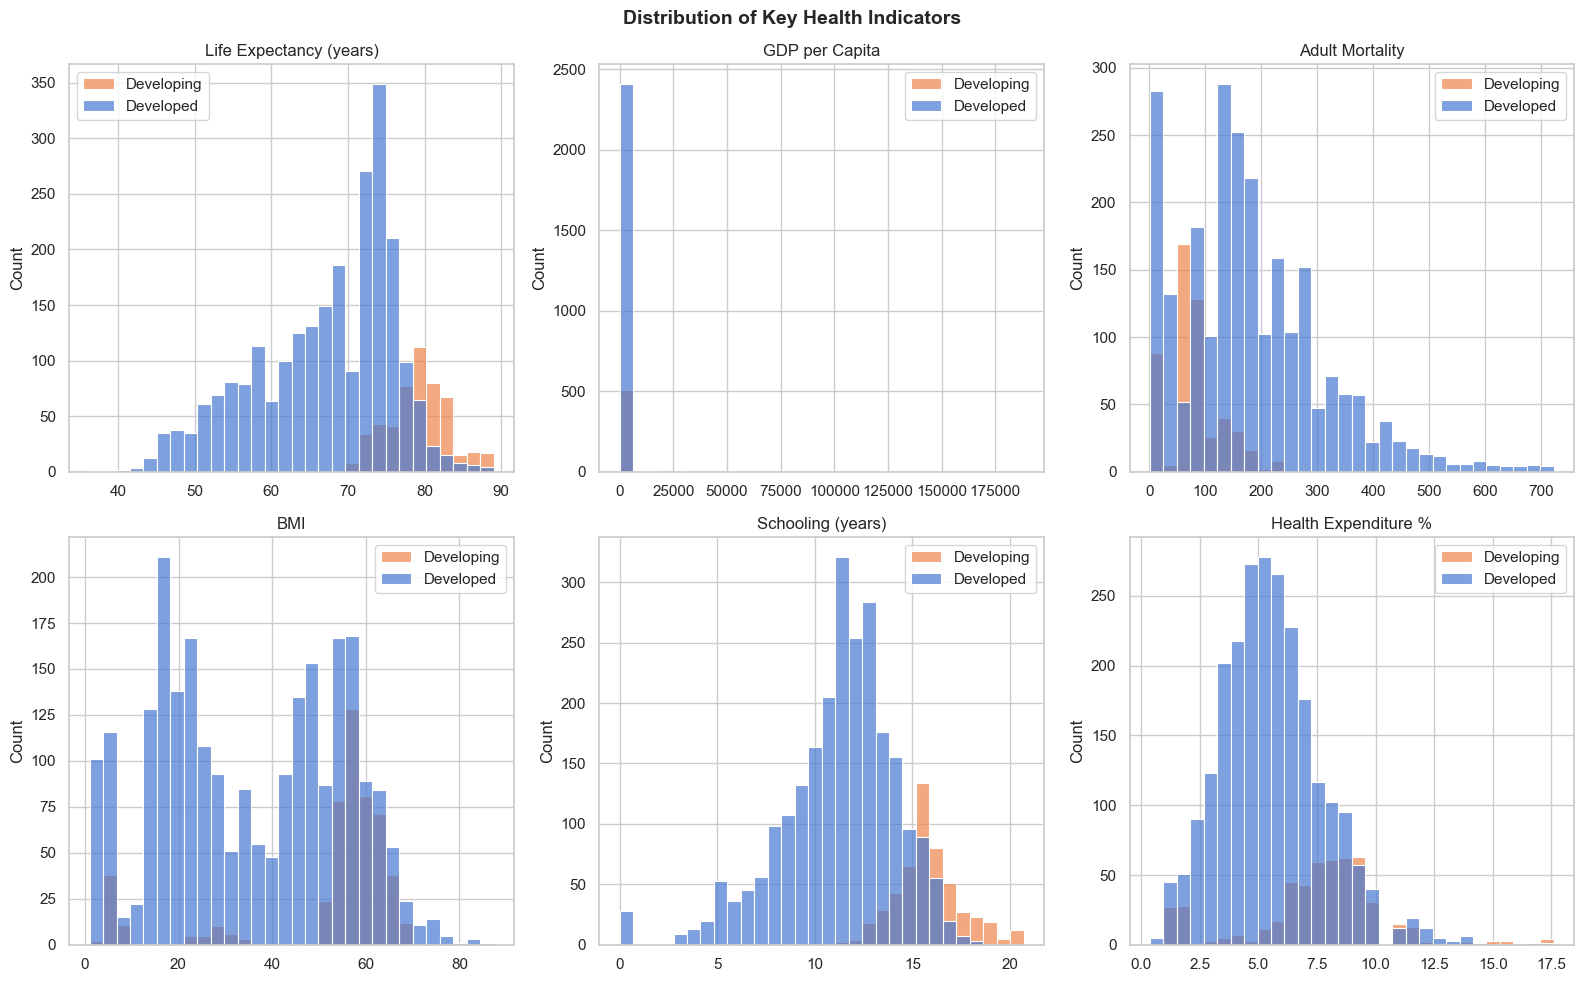

In [6]:
'''DISTRIBUTION ANALYSIS'''

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribution of Key Health Indicators", fontsize=14, fontweight="bold")

indicators = [
    ("life_expectancy", "Life Expectancy (years)"),
    ("gdp_per_capita", "GDP per Capita"),
    ("adult_mortality", "Adult Mortality"),
    ("bmi", "BMI"),
    ("schooling", "Schooling (years)"),
    ("total_expenditure", "Health Expenditure %")
]

for ax, (col, label) in zip(axes.flatten(), indicators):
    sns.histplot(data=df, x=col, hue="status", bins=30, ax=ax, alpha=0.7)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.legend(title="", labels=["Developing", "Developed"])

plt.tight_layout()
plt.show()

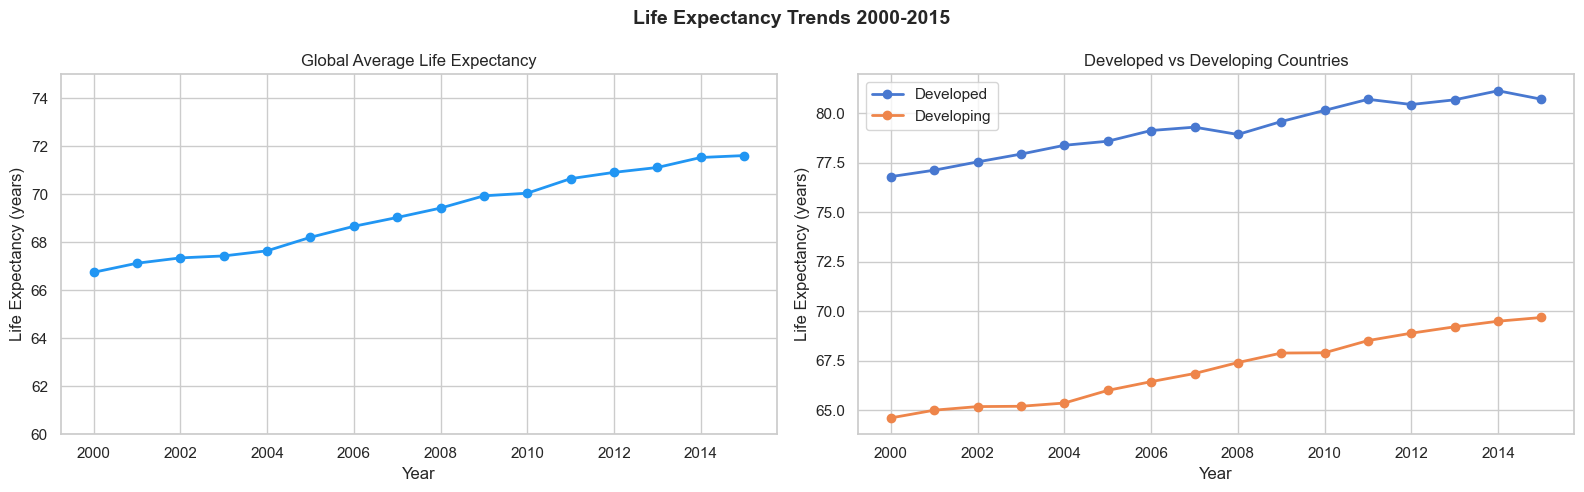

In [8]:
'''Life Expectancy Trend Overtime'''

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Life Expectancy Trends 2000-2015", fontsize=14, fontweight="bold")

# global average trend
global_trend = df.groupby("year")["life_expectancy"].mean().reset_index()
axes[0].plot(global_trend["year"], global_trend["life_expectancy"], 
             marker="o", linewidth=2, color="#2196F3")
axes[0].set_title("Global Average Life Expectancy")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Life Expectancy (years)")
axes[0].set_ylim(60, 75)

# developed vs developing
status_trend = df.groupby(["year", "status"])["life_expectancy"].mean().reset_index()
for status, group in status_trend.groupby("status"):
    axes[1].plot(group["year"], group["life_expectancy"], 
                 marker="o", linewidth=2, label=status)
axes[1].set_title("Developed vs Developing Countries")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Life Expectancy (years)")
axes[1].legend()

plt.tight_layout()
plt.show()

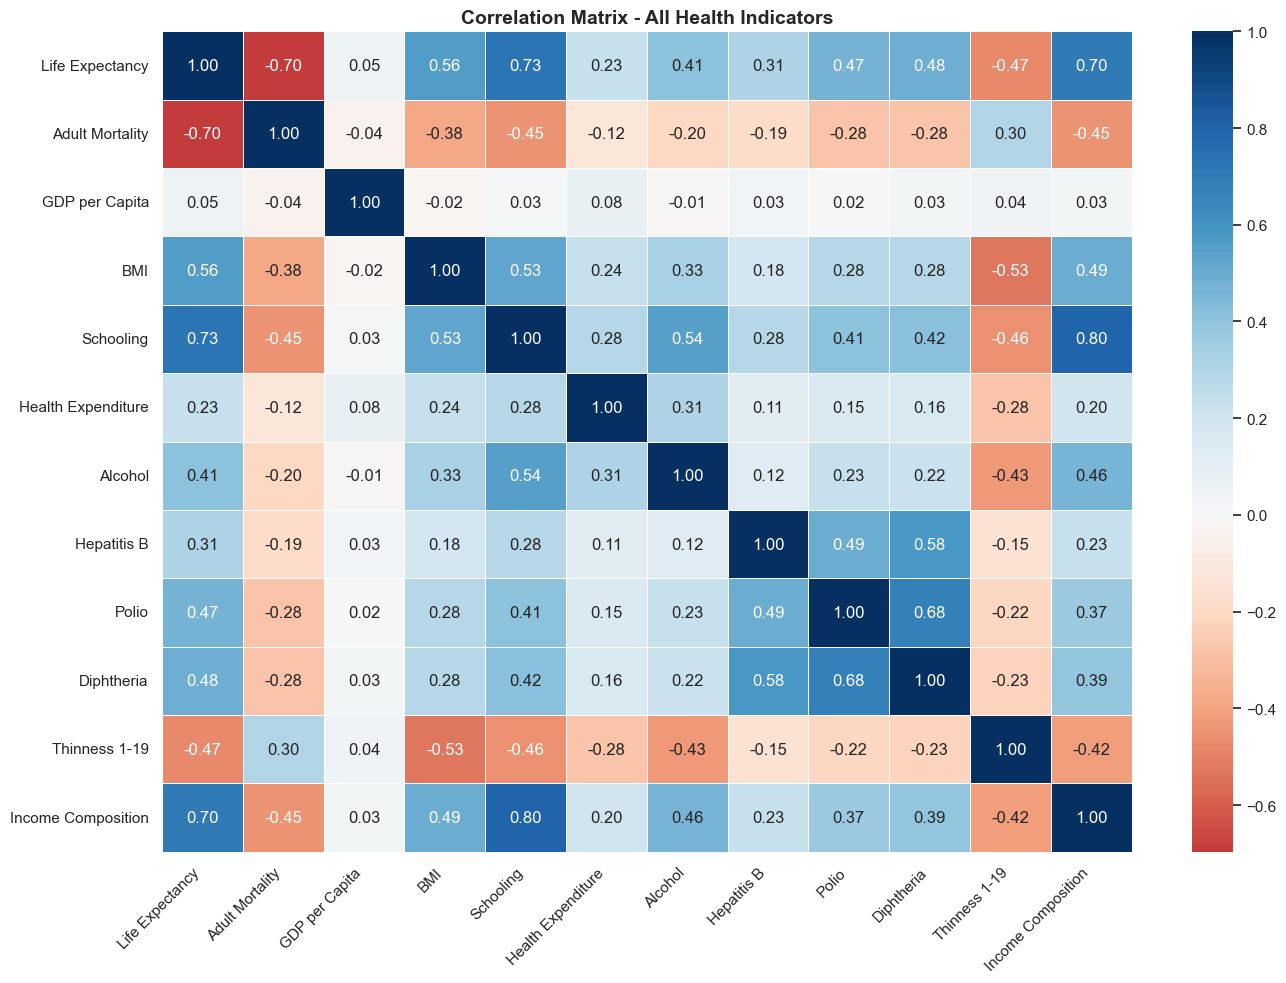

In [10]:
'''HEATMAP'''
fig, ax = plt.subplots(figsize=(14, 10))

corr_cols = [
    "life_expectancy", "adult_mortality", "gdp_per_capita",
    "bmi", "schooling", "total_expenditure", "alcohol",
    "hepatitis_b", "polio", "diphtheria", "thinness_1_19_years",
    "income_composition_of_resources"
]

corr_matrix = df[corr_cols].corr()

labels = [
    "Life Expectancy", "Adult Mortality", "GDP per Capita",
    "BMI", "Schooling", "Health Expenditure",
    "Alcohol", "Hepatitis B", "Polio",
    "Diphtheria", "Thinness 1-19", "Income Composition"
]

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0,
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
    linewidths=0.5
)

ax.set_title("Correlation Matrix - All Health Indicators", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

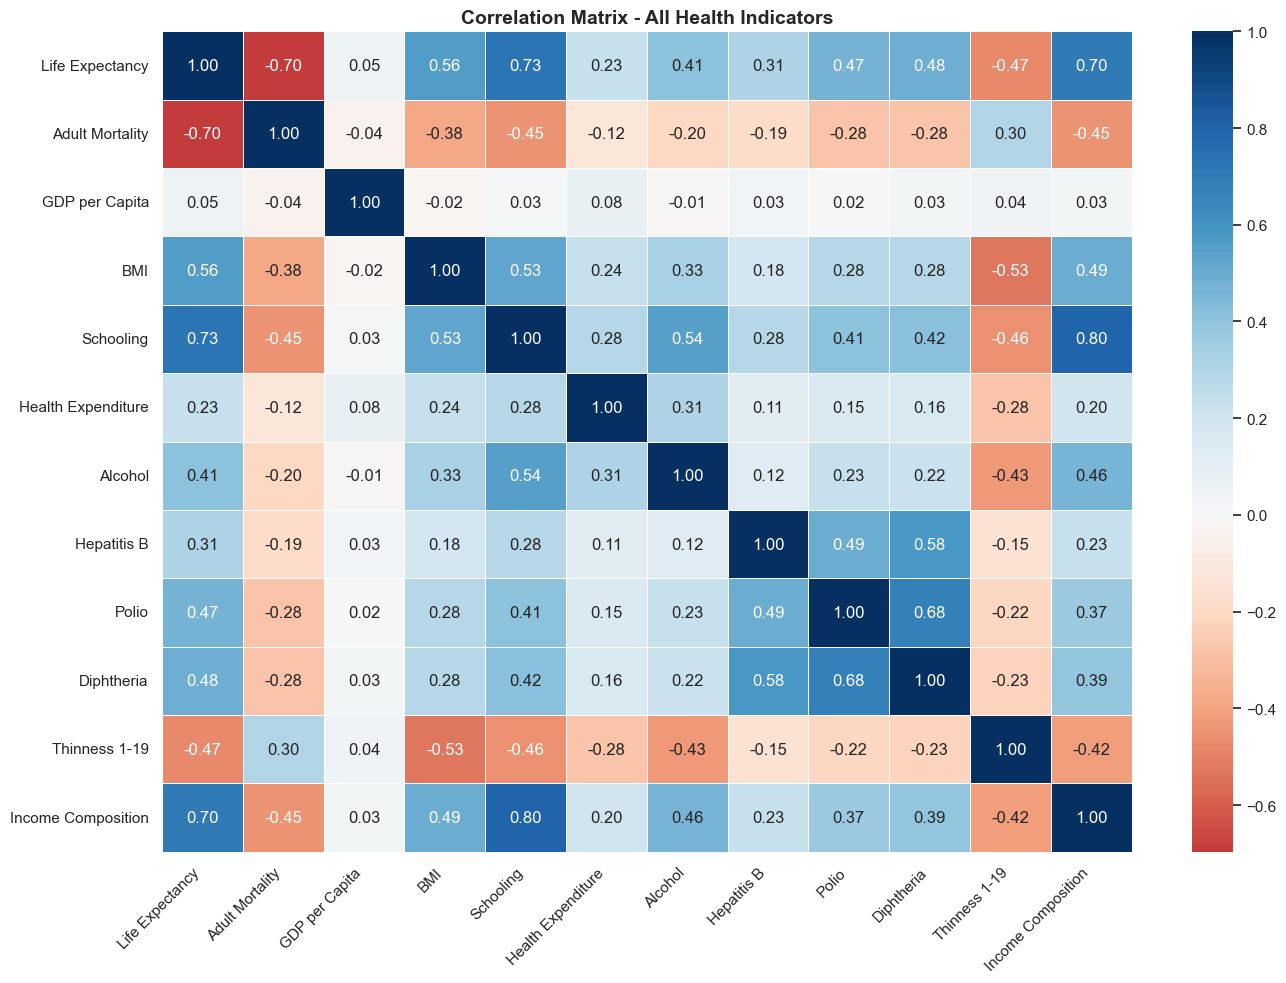

In [12]:
fig, ax = plt.subplots(figsize=(14, 10))

corr_cols = [
    "life_expectancy", "adult_mortality", "gdp_per_capita",
    "bmi", "schooling", "total_expenditure", "alcohol",
    "hepatitis_b", "polio", "diphtheria", "thinness_1_19_years",
    "income_composition_of_resources"
]

corr_matrix = df[corr_cols].corr()

labels = [
    "Life Expectancy", "Adult Mortality", "GDP per Capita",
    "BMI", "Schooling", "Health Expenditure",
    "Alcohol", "Hepatitis B", "Polio",
    "Diphtheria", "Thinness 1-19", "Income Composition"
]

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0,
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
    linewidths=0.5
)

ax.set_title("Correlation Matrix - All Health Indicators", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

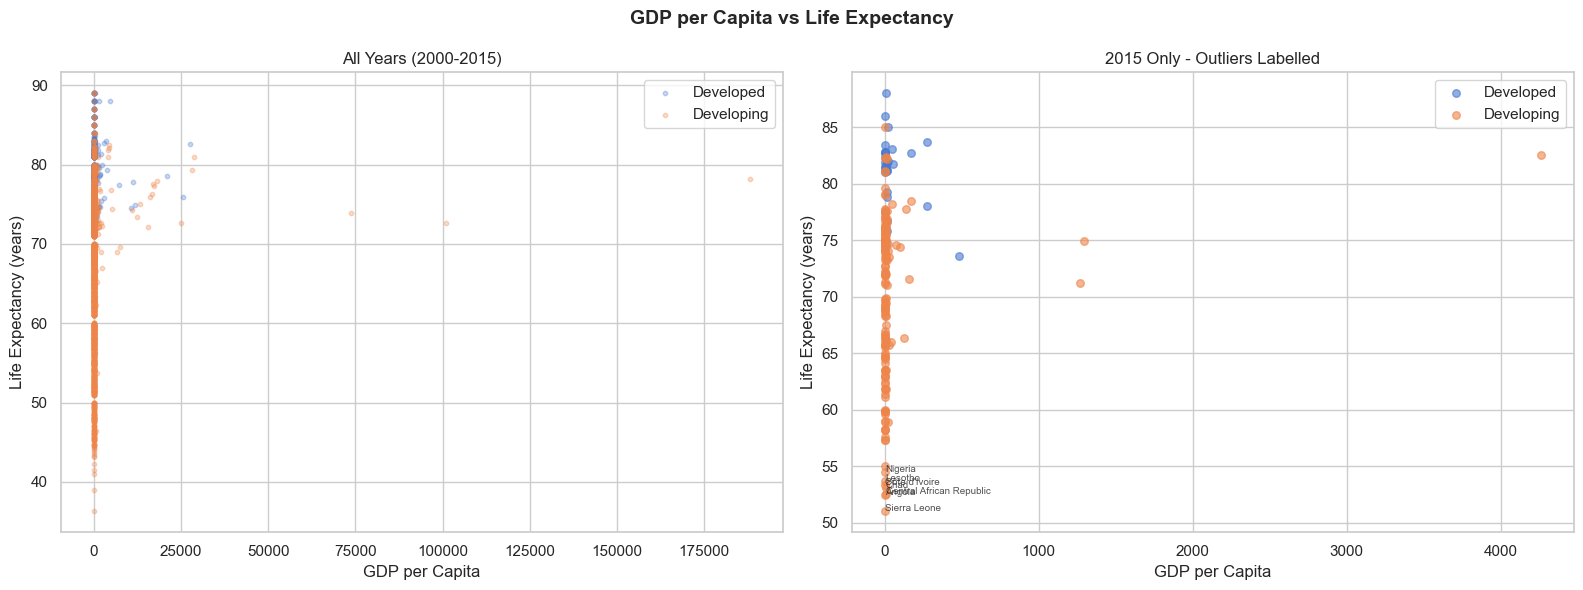

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("GDP per Capita vs Life Expectancy", fontsize=14, fontweight="bold")

# all years
scatter_df = df[["gdp_per_capita", "life_expectancy", "status", "country", "year"]].dropna()

for status, group in scatter_df.groupby("status"):
    axes[0].scatter(
        group["gdp_per_capita"],
        group["life_expectancy"],
        alpha=0.3,
        label=status,
        s=10
    )

axes[0].set_title("All Years (2000-2015)")
axes[0].set_xlabel("GDP per Capita")
axes[0].set_ylabel("Life Expectancy (years)")
axes[0].legend()

# 2015 only with country labels for outliers
latest_scatter = scatter_df[scatter_df["year"] == 2015]

for status, group in latest_scatter.groupby("status"):
    axes[1].scatter(
        group["gdp_per_capita"],
        group["life_expectancy"],
        alpha=0.6,
        label=status,
        s=30
    )

# label outliers
outliers = latest_scatter[
    (latest_scatter["life_expectancy"] < 55) |
    (latest_scatter["gdp_per_capita"] > 50000)
]
for _, row in outliers.iterrows():
    axes[1].annotate(
        row["country"],
        (row["gdp_per_capita"], row["life_expectancy"]),
        fontsize=7,
        alpha=0.8
    )

axes[1].set_title("2015 Only - Outliers Labelled")
axes[1].set_xlabel("GDP per Capita")
axes[1].set_ylabel("Life Expectancy (years)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
print("=" * 60)
print("KEY FINDINGS - WHO GLOBAL HEALTH EDA")
print("=" * 60)

# finding 1 — global life expectancy improvement
le_2000 = df[df["year"] == 2000]["life_expectancy"].mean()
le_2015 = df[df["year"] == 2015]["life_expectancy"].mean()
improvement = le_2015 - le_2000
print(f"\n1. GLOBAL LIFE EXPECTANCY")
print(f"   2000: {le_2000:.1f} years")
print(f"   2015: {le_2015:.1f} years")
print(f"   Improvement: +{improvement:.1f} years over 15 years")

# finding 2 — gap between developed and developing
dev_2015 = df[(df["year"] == 2015) & (df["status"] == "Developed")]["life_expectancy"].mean()
devg_2015 = df[(df["year"] == 2015) & (df["status"] == "Developing")]["life_expectancy"].mean()
gap = dev_2015 - devg_2015
print(f"\n2. DEVELOPED vs DEVELOPING GAP (2015)")
print(f"   Developed:  {dev_2015:.1f} years")
print(f"   Developing: {devg_2015:.1f} years")
print(f"   Gap: {gap:.1f} years")

# finding 3 — strongest correlations with life expectancy
corr_with_le = df[corr_cols].corr()["life_expectancy"].drop("life_expectancy").sort_values(ascending=False)
print(f"\n3. STRONGEST CORRELATIONS WITH LIFE EXPECTANCY")
for indicator, corr_val in corr_with_le.head(4).items():
    print(f"   {indicator}: {corr_val:.3f}")
print(f"   ...")
for indicator, corr_val in corr_with_le.tail(2).items():
    print(f"   {indicator}: {corr_val:.3f}")

# finding 4 — highest and lowest life expectancy 2015
highest = df[df["year"] == 2015].nlargest(1, "life_expectancy")[["country", "life_expectancy"]].values[0]
lowest = df[df["year"] == 2015].nsmallest(1, "life_expectancy")[["country", "life_expectancy"]].values[0]
print(f"\n4. LIFE EXPECTANCY RANGE (2015)")
print(f"   Highest: {highest[0]} — {highest[1]:.1f} years")
print(f"   Lowest:  {lowest[0]} — {lowest[1]:.1f} years")
print(f"   Difference: {highest[1] - lowest[1]:.1f} years")

# finding 5 — health expenditure impact
high_spend = df[df["total_expenditure"] > df["total_expenditure"].quantile(0.75)]["life_expectancy"].mean()
low_spend = df[df["total_expenditure"] < df["total_expenditure"].quantile(0.25)]["life_expectancy"].mean()
print(f"\n5. HEALTH EXPENDITURE IMPACT")
print(f"   High spending countries avg life expectancy: {high_spend:.1f} years")
print(f"   Low spending countries avg life expectancy:  {low_spend:.1f} years")
print(f"   Difference: {high_spend - low_spend:.1f} years")

KEY FINDINGS - WHO GLOBAL HEALTH EDA

1. GLOBAL LIFE EXPECTANCY
   2000: 66.8 years
   2015: 71.6 years
   Improvement: +4.9 years over 15 years

2. DEVELOPED vs DEVELOPING GAP (2015)
   Developed:  80.7 years
   Developing: 69.7 years
   Gap: 11.0 years

3. STRONGEST CORRELATIONS WITH LIFE EXPECTANCY
   schooling: 0.728
   income_composition_of_resources: 0.703
   bmi: 0.561
   diphtheria: 0.484
   ...
   thinness_1_19_years: -0.471
   adult_mortality: -0.696

4. LIFE EXPECTANCY RANGE (2015)
   Highest: Slovenia — 88.0 years
   Lowest:  Sierra Leone — 51.0 years
   Difference: 37.0 years

5. HEALTH EXPENDITURE IMPACT
   High spending countries avg life expectancy: 73.8 years
   Low spending countries avg life expectancy:  67.6 years
   Difference: 6.2 years
